# Compute temporal autocorrelation on detrended disc-averaged data

In [1]:
import sys
import json
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


sys.path.append("scripts/utils/")
from Microscopes import Holomonitor, Tomocube
from SegmentedCells import SegmentedCells
from file_operations import load_stack

data_path = "../../../../hdd_data/silja/Monolayers/"

### Define function for computing temporal autocorrelation on image

In [2]:
def temporal_autocorrelation(arr):  

    # Initializing empty array
    auto_corr = np.zeros([len(arr), len(arr)])
    
    # First element is just 1
    auto_corr[:,0] = np.mean(arr**2, axis=(1,2)) / np.mean(arr**2, axis=(1,2))

    # Loop through time lags
    for dt in range(1,len(arr)):
        
        # heights at later time
        arr_dt = np.roll(arr, axis=0, shift=-dt)

        arr_arr_dt = np.mean(arr * arr_dt, axis=(1,2))
        arr_rms    = np.sqrt(np.mean(arr**2, axis=(1,2)) * np.mean(arr_dt**2, axis=(1,2)))

        auto_corr[:-dt,dt] = (arr_arr_dt / arr_rms)[:-dt]

    return np.ma.array(auto_corr, mask=0)

In [3]:
measure = "disc"

### Load data

In [4]:
dataset = "MDCK_20240319_A1-13"
config = json.load(open(f"configs/{dataset}.json"))

### SET MICROSCOPE ###
if config['microscope'] == "holomonitor": microscope = Holomonitor()
elif config['microscope'] == "tomocube":  microscope = Tomocube()


h_pix  = load_stack(f"{data_path}height_fields/calibrated/{dataset}/", config, data_type="cells")

cells   = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")
density = cells.density.astype("int")

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-13_cells.p.


/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/numpy/ma/core.py:502: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)


In [5]:
if measure == "disc":
    # Compute blur radius in unist of pixels
    r_cell = 10**3*np.sqrt(1 / (density * np.pi)) / microscope.pix_to_um
    sigma  = microscope.rblur * r_cell

    h_disc = []
    for f in range(np.min([len(sigma), len(h_pix)])):

        # Apply Gaussian blur to data
        h_disc.append(gaussian_filter(h_pix[f], sigma[f]))

    h_disc = np.array(h_disc)

    im = h_disc

elif measure == "pixel":
    im = h_pix

### Detrend array

In [6]:
# detrend per pixel
data = np.copy(im)

# data: shape (T, Ny, Nx), dtype float32/float64
T = data.shape[0]

# Time coordinate (0, 1, 2, ..., T-1)
time = np.arange(T, dtype=data.dtype)
time_mean = time.mean()           # scalar: mean(time)
time_var = ((time - time_mean) ** 2).sum()  # scalar: variance * T

# Mean value over time at each (y, x)
spatial_mean_over_time = data.mean(axis=0)

# Covariance between time and data for each (y, x):
cov_time_data = ((time[:, None, None] - time_mean) *
                 (data - spatial_mean_over_time)).sum(axis=0)

# slope(y, x)
trend_slope = cov_time_data / time_var

In [7]:
# Detrend heights with respect to population average
#h_detrended = im - im.mean(axis=(1,2), keepdims=True)

# Detrend wrt "cell" average
h_detrended = im - (trend_slope[None, :, :] * time[:, None, None])

In [8]:
#h_detrended = h_detrended[:, 100:900, 100:900]

# Remove position average to capture fluctuations
h_var = h_detrended - h_detrended.mean(axis=(0), keepdims=True)

### Compute autocorrelation

In [9]:
correlation = temporal_autocorrelation(h_var)
correlation = np.ma.array(correlation, mask=correlation==0)

In [10]:
# Create density bin edges
density_bin = 100
min_bin = 100 * int(np.min(density[density > 0])/100)
max_bin = 100 * int(np.max(density)/100) + density_bin
bins = np.arange(min_bin, max_bin + 100+1, density_bin)

# Count instances per bin
density_idx = [np.digitize(rho, bins) for rho in density]

density_correlation = []

for i in range(len(bins)):
    tmp_correlation = []

    for corr, rho_idx in zip(correlation, density_idx):
        
        # Bin data by density
        mask = (rho_idx == i)
        tmp_correlation.append(corr[mask])

    tmp_correlation = np.ma.concatenate(tmp_correlation)
    density_correlation.append(np.ma.mean(tmp_correlation, axis=0))

/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/numpy/ma/core.py:5445: RuntimeWarning: Mean of empty slice.
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
/home/silja/Documents/MDCK-QPI/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


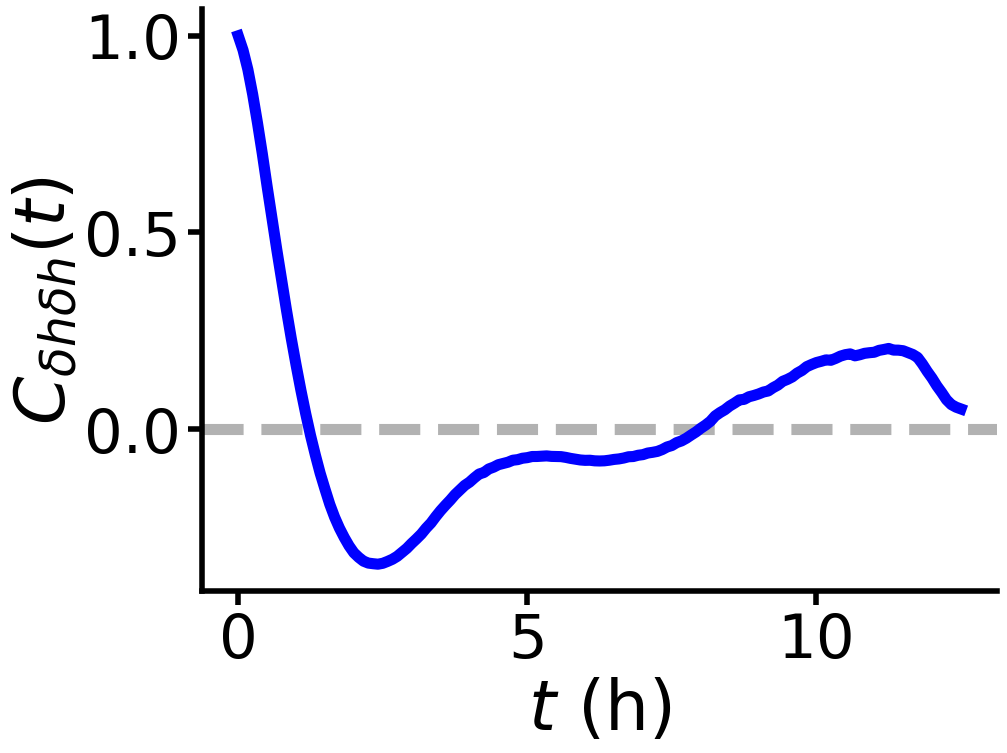

In [11]:
# Plot
# plot parameters
lw = 8

font  = {'size': 50}
lines = {'lw' : 4}
axes  = {'lw' : 4}
mpl.rc('font', **font)
mpl.rc('lines', **lines)
mpl.rc('axes', **axes)
mpl.rc('xtick.major', size = 10, pad = 5, width=4)
mpl.rc('ytick.major', size = 10, pad = 5, width=4)
mpl.rc('xtick', labelsize=44)
mpl.rc('ytick', labelsize=44)


fig, ax = plt.subplots(1, 1, figsize=(10,7.5))

fig.subplots_adjust(left=1/5,
                    right=0.995,
                    bottom=1.1/5,
                    top=0.995)
time = np.arange(len(correlation)) * microscope.frame_to_h

# fig, ax = plt.subplots(1, 1, figsize=(13.5,9))

plt.axhline(0, ls="dashed", lw=lw, color="gray", alpha=0.6)

color = mpl.colormaps["Blues_r"](np.linspace(0, 0.7, len(density_correlation)))

plt.plot(time, np.ma.mean(correlation, axis=0), "-", lw=lw, c="b")

plt.xlabel(r"$t$ (h)");
plt.ylabel(r"$C_{\delta h \delta h}(t)$")
sns.despine(fig)
# fig.savefig(f"figs/Elife/subfigures/{measure}wise_autocorrelation_pixel_mean_detrended_full.svg")
#fig.savefig("results/tmp/autocorrelation_A1-13.svg")